# Scaling method selection for metabolomics data

이 노트북은 **전처리 실행 전에 scaling 방법을 선택**하기 위한 전용 notebook입니다.

포함 내용:
- raw 데이터 불러오기
- raw intensity 분포 시각화
- log10 변환 후 분포 비교
- sample-wise total intensity 확인
- scaling 방법별 PCA 비교 (`none`, `pareto`, `auto`, `log_pareto`)
- QC clustering 기반 간단한 추천


## 1. Load packages

In [19]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

## 2. Load raw dataset

필수 조건:
- `Name` 열 포함
- `Label` 열 포함
- 나머지 feature 열은 numeric 이어야 함


In [20]:
cd C:\Users\tr432\Downloads\Metabolomics_GutLungAxis_re-pipeline

C:\Users\tr432\Downloads\Metabolomics_GutLungAxis_re-pipeline


In [29]:
original_dataset = pd.read_excel('Compounds_merged.xlsx', sheet_name='serum_pos_tp')
original_dataset.head(3)

,Name,Label,286.31052-14.933,127.03897-1.441,258.27917-14.002,61.03969-1.062,496.33995-14.389,172.07169-4.382,520.34-13.811,73.06478-1.434,...,437.22062-12.514,420.039-9.53,674.89818-0.956,288.86105-0.885,277.20115-13.158,363.27442-15.162,316.18052-7.669,290.8553-0.999,361.88999-0.954,243.88082-0.929
0,BL1,blank,2.553798e+09,2.408801e+09,1.052799e+09,1.606881e+07,6.844526e+06,1.157801e+06,4.665339e+06,9.523904e+08,...,174564.003914,45120.025106,31511.869455,36918.812811,82015.991455,86558.270894,44153.105968,27466.673498,31892.667997,27957.952011
1,BL2,blank,7.353271e+08,3.093175e+08,3.085743e+08,1.156592e+07,7.209158e+06,1.979458e+06,4.026565e+06,9.213781e+08,...,41042.848642,178917.414417,26491.062875,35870.846374,132482.017757,58748.373735,84248.202332,29747.949939,26811.188539,25098.232082
2,BL3,blank,2.343091e+09,2.138201e+08,1.066110e+09,1.341865e+07,7.519924e+06,4.812889e+05,3.482413e+06,9.780546e+08,...,84279.159043,80750.705953,28004.036185,35433.944654,141314.379995,78779.828343,140399.253679,29046.808985,28342.445056,24752.054175


## 3. Check raw data distribution before choosing scaling

이 단계는 사용자가 **직접 분포를 보고 scaling 방법을 판단**할 수 있도록 도와줍니다.

확인 포인트:
- raw 값이 오른쪽으로 많이 치우쳐 있는가?
- log10 변환 후 분포가 더 안정적으로 보이는가?
- 몇 개의 큰 feature가 전체를 지배하는가?
- QC 분포는 어떤가?


In [30]:
def plot_raw_distribution(original_dataset, qc_label='Mix'):
    feature_cols = [col for col in original_dataset.columns if col not in ['Name', 'Label']]
    X = original_dataset[feature_cols].copy()

    all_values = X.to_numpy().flatten()
    all_values = all_values[~np.isnan(all_values)]
    positive_values = all_values[all_values > 0]

    print('Number of samples:', original_dataset.shape[0])
    print('Number of features:', len(feature_cols))
    print('\nSummary of first 10 features:')
    display(X.describe().T[['mean', 'std', 'min', '50%', 'max']].head(10))

    plt.figure(figsize=(7, 4))
    plt.hist(all_values, bins=50)
    plt.xlabel('Raw intensity')
    plt.ylabel('Frequency')
    plt.title('Distribution of all raw feature values')
    plt.tight_layout()
    plt.show()

    if len(positive_values) > 0:
        plt.figure(figsize=(7, 4))
        plt.hist(np.log10(positive_values), bins=50)
        plt.xlabel('log10(raw intensity)')
        plt.ylabel('Frequency')
        plt.title('Distribution after log10 transform')
        plt.tight_layout()
        plt.show()
    else:
        print('No positive values were found for log10 transformation.')

    sample_total = X.sum(axis=1)
    plt.figure(figsize=(7, 4))
    plt.boxplot(sample_total)
    plt.ylabel('Sum of feature intensities per sample')
    plt.title('Sample-wise total intensity distribution')
    plt.tight_layout()
    plt.show()

    if qc_label in original_dataset['Label'].astype(str).unique():
        qc_df = original_dataset[original_dataset['Label'] == qc_label]
        qc_values = qc_df[feature_cols].to_numpy().flatten()
        qc_values = qc_values[~np.isnan(qc_values)]

        plt.figure(figsize=(7, 4))
        plt.hist(qc_values, bins=50)
        plt.xlabel('QC raw intensity')
        plt.ylabel('Frequency')
        plt.title(f'Distribution of QC feature values ({qc_label})')
        plt.tight_layout()
        plt.show()
    else:
        print(f"QC label '{qc_label}' was not found in the dataset.")

    raw_skew = pd.Series(all_values).skew() if len(all_values) > 0 else np.nan
    log_skew = pd.Series(np.log10(positive_values)).skew() if len(positive_values) > 0 else np.nan

    feature_means = X.mean(axis=0)
    dynamic_range_ratio = np.nan
    if (feature_means > 0).any():
        dynamic_range_ratio = feature_means.max() / feature_means[feature_means > 0].min()

    print('\nInterpretation guide:')
    print(f'- Raw skewness: {raw_skew:.3f}' if pd.notna(raw_skew) else '- Raw skewness: NA')
    print(f'- Log10 skewness: {log_skew:.3f}' if pd.notna(log_skew) else '- Log10 skewness: NA')
    print(f'- Dynamic range ratio: {dynamic_range_ratio:.3f}' if pd.notna(dynamic_range_ratio) else '- Dynamic range ratio: NA')
    print('\nPractical hints:')
    print('- If raw distribution is strongly right-skewed, log transform may help.')
    print('- If a few large features dominate, pareto or auto scaling may be useful.')
    print('- Pareto is often a balanced default for metabolomics.')
    print('- Auto scaling can emphasize small features but may amplify noise.')


Number of samples: 21
Number of features: 1926

Summary of first 10 features:


,mean,std,min,50%,max
286.31052-14.933,1.171433e+09,9.104039e+08,3.276148e+08,8.568503e+08,3.338315e+09
127.03897-1.441,3.708714e+08,4.678954e+08,2.123569e+08,2.833620e+08,2.408801e+09
258.27917-14.002,7.100194e+08,5.084707e+08,2.160174e+08,5.839049e+08,2.092576e+09
61.03969-1.062,9.924595e+08,4.953307e+08,1.156592e+07,1.031829e+09,1.987991e+09
496.33995-14.389,1.246697e+09,5.694299e+08,6.844526e+06,1.500436e+09,1.782529e+09
172.07169-4.382,3.106870e+08,5.573275e+08,4.789378e+05,1.588836e+06,1.693766e+09
520.34-13.811,9.124965e+08,4.499648e+08,3.482413e+06,1.072732e+09,1.393893e+09
73.06478-1.434,1.081716e+09,1.283145e+08,8.262487e+08,1.096747e+09,1.298245e+09
59.04923-1.431,1.062981e+09,9.140740e+07,9.239849e+08,1.076436e+09,1.293087e+09
79.02112-1.1,7.881148e+08,1.466037e+08,4.193289e+08,7.647366e+08,9.661930e+08


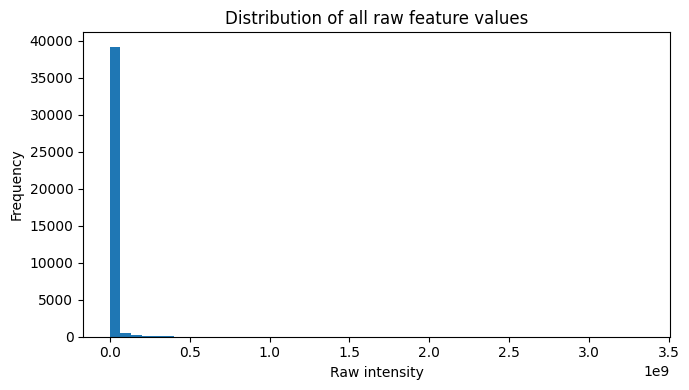

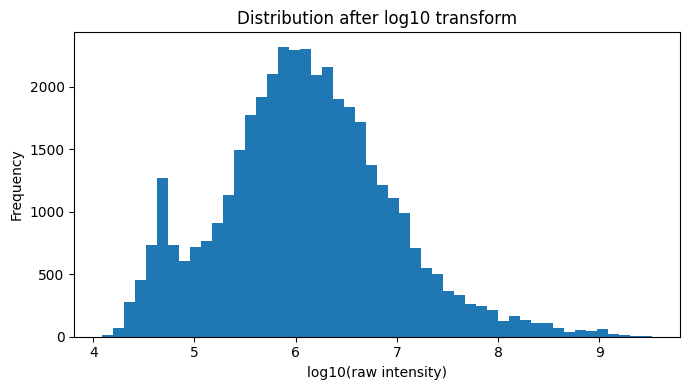

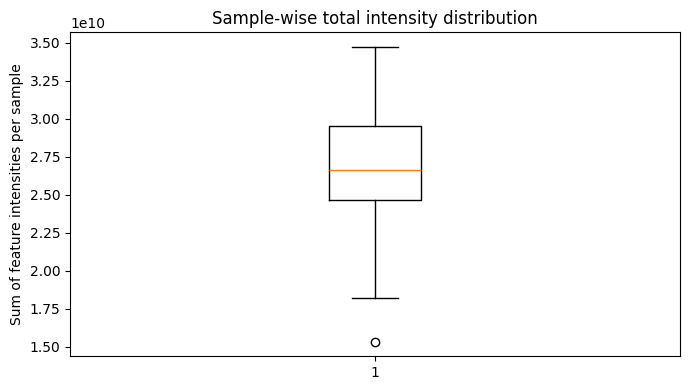

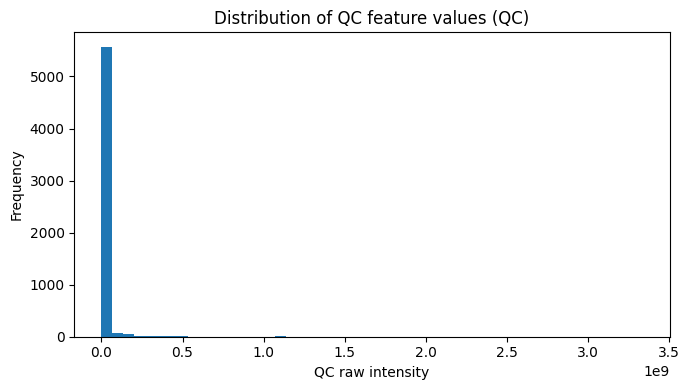


Interpretation guide:
- Raw skewness: 14.792
- Log10 skewness: 0.343
- Dynamic range ratio: 23632.219

Practical hints:
- If raw distribution is strongly right-skewed, log transform may help.
- If a few large features dominate, pareto or auto scaling may be useful.
- Pareto is often a balanced default for metabolomics.
- Auto scaling can emphasize small features but may amplify noise.


In [31]:
plot_raw_distribution(original_dataset, qc_label='QC')

## 4. Compare scaling methods by PCA

이 단계에서는 scaling 방법별로 PCA를 그리고,
QC sample이 얼마나 잘 뭉치는지(`qc_cluster_score`)를 비교합니다.

해석 포인트:
- `qc_cluster_score`가 작을수록 QC가 더 잘 뭉침
- 군 분리가 커 보여도 QC가 불안정하면 좋은 scaling이 아닐 수 있음


In [32]:
def _apply_scaling_matrix(X, method='none'):
    X = X.copy()
    
    if method == 'none':
        return X

    mean_val = X.mean(axis=0)
    sd_val = X.std(axis=0, ddof=1).replace(0, np.nan)

    if method == 'pareto':
        return (X - mean_val) / np.sqrt(sd_val)
    elif method == 'auto':
        return (X - mean_val) / sd_val
    else:
        raise ValueError("method must be one of: 'none', 'pareto', 'auto'")

def _apply_log10_transform(X):
    X = X.copy()
    min_positive = X[X > 0].min().min()
    if pd.isna(min_positive):
        raise ValueError('No positive values found for log10 transform.')
    pseudo = min_positive / 2
    return np.log10(X + pseudo)

def _qc_cluster_score(pca_df, qc_label='Mix'):
    qc = pca_df[pca_df['Label'] == qc_label].copy()
    if len(qc) < 2:
        return np.nan
    center = qc[['PC1', 'PC2']].mean(axis=0)
    dist = np.sqrt(((qc[['PC1', 'PC2']] - center) ** 2).sum(axis=1))
    return dist.mean()

def compare_scaling_methods_pca(original_dataset, qc_label='Mix', methods=None):
    if methods is None:
        methods = ['none', 'pareto', 'auto', 'log_pareto', 'log_auto']

    feature_cols = [col for col in original_dataset.columns if col not in ['Name', 'Label']]
    X_raw = original_dataset[feature_cols].copy()
    sample_info = original_dataset[['Name', 'Label']].copy()

    results = []
    pca_outputs = {}

    for method in methods:
        X = X_raw.copy()

        if method == 'none':
            X_proc = X
        elif method == 'pareto':
            X_proc = _apply_scaling_matrix(X, method='pareto')
        elif method == 'auto':
            X_proc = _apply_scaling_matrix(X, method='auto')
        elif method == 'log_pareto':
            X_log = _apply_log10_transform(X)
            X_proc = _apply_scaling_matrix(X_log, method='pareto')
        elif method == 'log_auto':
            X_log = _apply_log10_transform(X)
            X_proc = _apply_scaling_matrix(X_log, method='auto')
        else:
            raise ValueError(f'Unknown method: {method}')

        X_proc = X_proc.replace([np.inf, -np.inf], np.nan)
        X_proc = X_proc.dropna(axis=1, how='any')

        pca = PCA(n_components=2)
        scores = pca.fit_transform(X_proc)
        explained = pca.explained_variance_ratio_ * 100

        pca_df = sample_info.copy()
        pca_df['PC1'] = scores[:, 0]
        pca_df['PC2'] = scores[:, 1]

        qc_score = _qc_cluster_score(pca_df, qc_label=qc_label)

        results.append({
            'method': method,
            'n_features_used': X_proc.shape[1],
            'PC1_explained_percent': explained[0],
            'PC2_explained_percent': explained[1],
            'qc_cluster_score': qc_score
        })

        pca_outputs[method] = {
            'pca_df': pca_df,
            'explained': explained
        }

    result_df = pd.DataFrame(results).sort_values('qc_cluster_score', na_position='last').reset_index(drop=True)
    return result_df, pca_outputs

def plot_scaling_method_pca(pca_outputs):
    for method, obj in pca_outputs.items():
        pca_df = obj['pca_df']
        explained = obj['explained']

        plt.figure(figsize=(6, 5))
        labels = pca_df['Label'].dropna().unique()

        for label in labels:
            tmp = pca_df[pca_df['Label'] == label]
            plt.scatter(tmp['PC1'], tmp['PC2'], label=label)

        plt.xlabel(f"PC1 ({explained[0]:.1f}%)")
        plt.ylabel(f"PC2 ({explained[1]:.1f}%)")
        plt.title(f'PCA after {method}')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()


,method,n_features_used,PC1_explained_percent,PC2_explained_percent,qc_cluster_score
0,log_pareto,1926,73.412771,6.082635,3.103358e+00
1,auto,1926,42.430480,12.426496,1.117575e+01
2,log_auto,1926,60.476755,8.699938,1.691885e+01
3,pareto,1926,45.040753,13.851270,4.712038e+04
4,none,1926,43.315971,26.227420,1.102984e+09


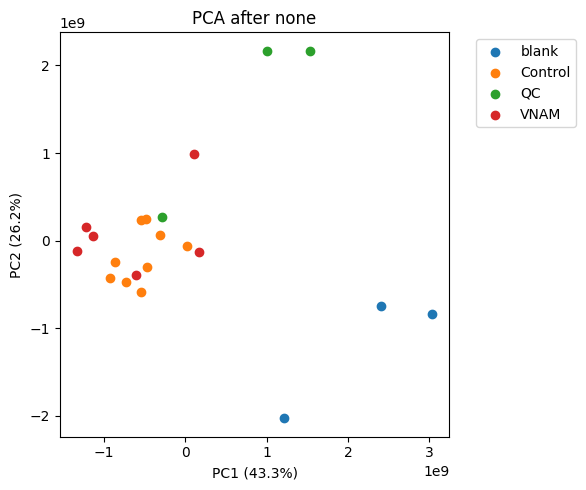

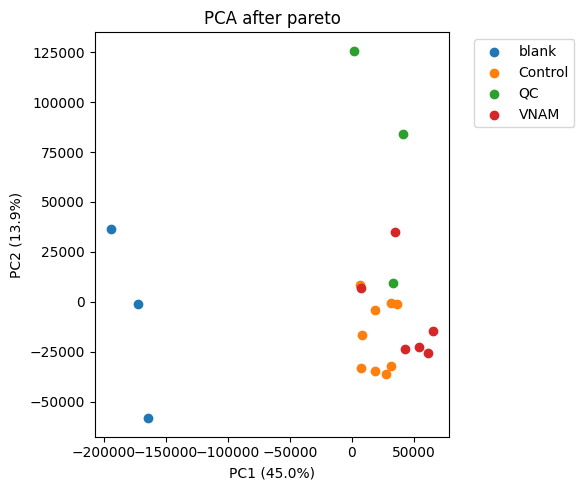

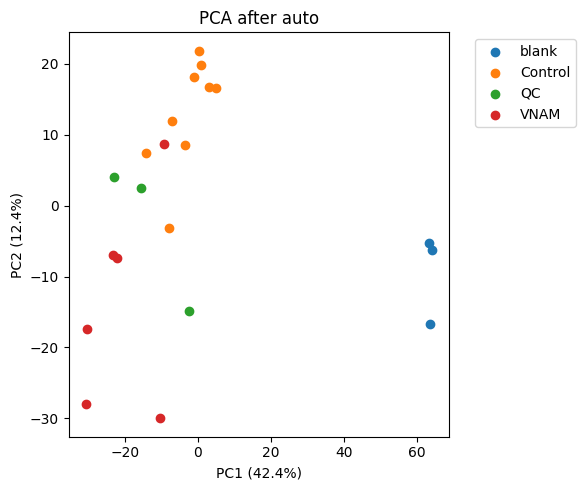

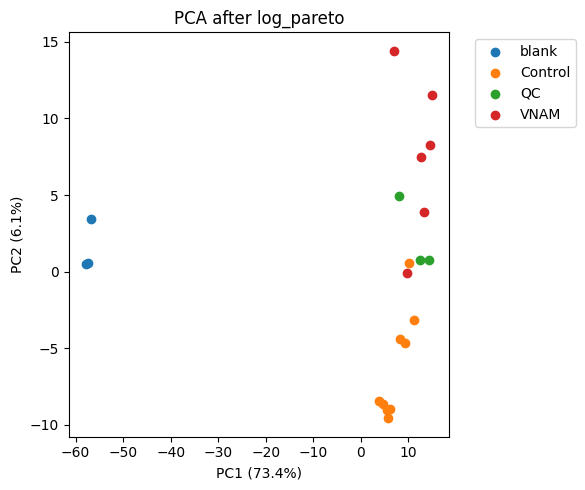

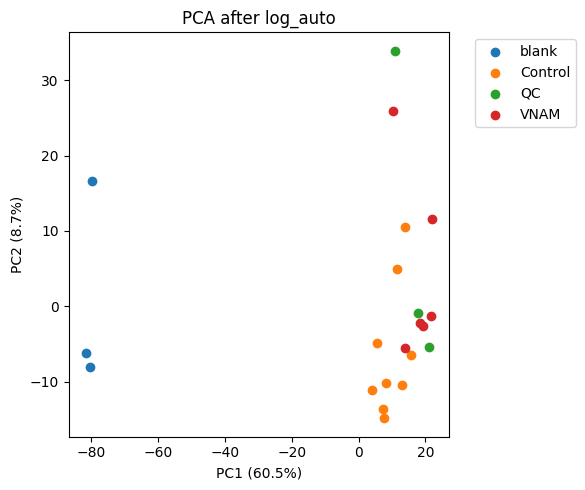

In [33]:
result_df, pca_outputs = compare_scaling_methods_pca(original_dataset, qc_label='QC')
display(result_df)
plot_scaling_method_pca(pca_outputs)

## 5. Automatic recommendation text

아래 셀은 PCA 결과를 바탕으로 간단한 추천 문구를 출력합니다.
최종 선택은 반드시 그림도 함께 보고 판단하세요.


In [34]:
def make_scaling_recommendation_text(result_df):
    if result_df is None or len(result_df) == 0:
        print('No PCA comparison results are available.')
        return None

    df_valid = result_df.dropna(subset=['qc_cluster_score']).copy()
    if len(df_valid) == 0:
        print('QC-based recommendation is not available.')
        print('Please check whether QC samples exist and whether the QC label is correct.')
        return None

    best = df_valid.iloc[0]
    worst = df_valid.iloc[-1]

    print('=== Automatic recommendation ===')
    print(f"Best starting option based on QC clustering: {best['method']}")
    print(f"QC cluster score: {best['qc_cluster_score']:.4f}")
    print()
    print('Reasoning:')
    print(f"- Among the tested methods, '{best['method']}' produced the tightest QC clustering in PCA space.")
    print('- Tighter QC clustering generally suggests more stable technical behavior after scaling.')

    if best['method'] == 'log_pareto':
        print('- This often suggests that the raw data are right-skewed and benefit from log transform before scaling.')
    elif best['method'] == 'pareto':
        print('- This often suggests a balanced choice that reduces dominance of large features without over-amplifying noise.')
    elif best['method'] == 'auto':
        print('- This suggests equalizing variance helps, but you should still check whether noise is being amplified.')
    elif best['method'] == 'none':
        print('- This suggests that stronger scaling may not be improving QC behavior in this dataset.')

    print()
    print('Comparison note:')
    print(f"- The weakest tested option by QC clustering was '{worst['method']}' with qc_cluster_score = {worst['qc_cluster_score']:.4f}.")
    print()
    print('Practical advice:')
    print('- Use this recommendation as a starting point, not as an absolute rule.')
    print('- Also review the PCA plots directly and confirm that QC samples cluster tightly without suspicious distortion of biological groups.')
    print('- If two methods have very similar QC cluster scores, pareto is often the safer and more interpretable choice.')

    return {
        'recommended_method': best['method'],
        'recommended_qc_cluster_score': float(best['qc_cluster_score'])
    }


In [35]:
recommendation = make_scaling_recommendation_text(result_df)
recommendation

=== Automatic recommendation ===
Best starting option based on QC clustering: log_pareto
QC cluster score: 3.1034

Reasoning:
- Among the tested methods, 'log_pareto' produced the tightest QC clustering in PCA space.
- Tighter QC clustering generally suggests more stable technical behavior after scaling.
- This often suggests that the raw data are right-skewed and benefit from log transform before scaling.

Comparison note:
- The weakest tested option by QC clustering was 'none' with qc_cluster_score = 1102984227.3913.

Practical advice:
- Use this recommendation as a starting point, not as an absolute rule.
- Also review the PCA plots directly and confirm that QC samples cluster tightly without suspicious distortion of biological groups.
- If two methods have very similar QC cluster scores, pareto is often the safer and more interpretable choice.


{'recommended_method': 'log_pareto',
 'recommended_qc_cluster_score': 3.103357599165298}

## 6. Final note

추천된 scaling 방법을 확인한 뒤, 실제 preprocessing notebook에서 해당 방법을 넣어 사용하면 됩니다.

예:

```python
preprocessor = MetaboPreprocessor(
    step_blank_subtraction=True,
    step_filter_rsd=True,
    qc_label='Mix',
    blank_label='blank',
    scaling='pareto'
)
```
